# 1 Finding Co-located EMIT and NEON AOP Data

**Summary**  

The Earth surface Mineral dust source InvesTigation (EMIT) instrument is located on the International Space Station (ISS) and has collected data over a large area of the Continental US. The National Ecological Observatory Network (NEON) Airborne Observation Platform (AOP) collects aerial remote sensing data, including hyperspectral reflectance data over sites across the United States and Puerto Rico. In this notebook we will show how to utilize the [`earthaccess` Python library](https://github.com/nsidc/earthaccess) to find spatially overlapping EMIT and NEON reflectance data at NEON's [Soaproot Saddle](https://www.neonscience.org/field-sites/soap) site (SOAP) in California. In Sept 2020 and June 2021, the Creek Fire and Blue Fires burned portions of the site, so data at this site would be interesting to investigate wildfire disturbance and recovery.

**Background**

The **EMIT** instrument is an imaging spectrometer that measures light in visible (V) to short-wave (SWIR) infrared wavelengths; this is also referred to as a VSWIR sensor. These measurements display unique spectral signatures that correspond to the composition on the Earth's surface. The EMIT mission focuses specifically on mapping the composition of minerals to better understand the effects of mineral dust throughout the Earth system and human populations now and in the future. In addition, the EMIT instrument can be used in other applications, such as mapping of greenhouse gases, snow properties, and water resources.

More details about EMIT and its associated products can be found on the [EMIT website](https://earth.jpl.nasa.gov/emit/) and [EMIT product pages](https://lpdaac.usgs.gov/product_search/?query=EMIT&status=Operational&view=cards&sort=title) hosted by the LP DAAC.

The **NEON Imaging Spectrometer (NIS)** is an airborne [imaging spectrometer](https://www.neonscience.org/data-collection/imaging-spectrometer) built by JPL (AVIRIS-NG) and operated by the National Ecological Observatory Network's (NEON) Airborne Observation Platform (AOP). NEON's hyperspectral sensors collect measurements of sunlight reflected from the Earth's surface in 426 narrow (~5 nm) spectral channels spanning wavelengths between ~ 380 - 2500 nm. NEON's remote sensing data is intended to map and answer questions about a landscape, with ecological applications including identifying and classifying plant species and communities, mapping vegetation health, detecting disease or invasive species, and mapping droughts, wildfires, or other natural disturbances and their impacts. 

NEON surveys sites spanning the continental US, during peak phenological greenness, capturing each site 3 out of every 5 years, for most terrestrial sites. AOP's [Flight Schedules and Coverage](https://www.neonscience.org/data-collection/flight-schedules-coverage) provide's more information about the current and past schedules.

More detailed information about NEON's airborne sampling design can be found in the paper: [Spanning scales: The airborne spatial and temporal sampling design of the National Ecological Observatory Network](https://besjournals.onlinelibrary.wiley.com/doi/10.1111/2041-210X.13942).

**Requirements**  
 - [NASA Earthdata Account](https://urs.earthdata.nasa.gov/home)   
 - *No Python setup requirements if connected to the workshop cloud instance!*  
 - **Local Only** Set up Python Environment - See **setup_instructions.md** in the `/setup/` folder to set up a local compatible Python environment

 - NEON API Token (optional, but strongly recommended), see [NEON API Tokens Tutorial](https://www.neonscience.org/resources/learning-hub/tutorials/neon-api-tokens-tutorial) for more details on how to create and set up your token in Python (and R). Once you create your token (on the [NEON User Accounts](https://www.neonscience.org/about/user-accounts)) page, this notebook will show you how to set it as an environment variable and use it for downloading AOP data.

**Download the NEON Flight Boundary Shapefile:** <a href="https://www.neonscience.org/sites/default/files/AOP_flightBoxes_0.zip" class="link--button link--arrow">AOP_flightBoxes.zip</a>

**Learning Objectives**  
- Use functions provided in an external Python module to find and download available NEON airborne reflectance data.
- Use `earthaccess` to find EMIT data that overlaps with a NEON site.
- How to export a list of files and download them programmatically.  

**Tutorial Outline**  

1. Setup
2. Explore NEON sites and find available NEON reflectance data at the SOAP site
3. Download NEON reflectance data
4. Search for EMIT reflectance data overlapping with the NEON site
5. Organize and filter results to remove cloudy datasets
6. Visualize intersecting NEON-EMIT coverage
7. Create a list of EMIT asset URLs
8. Download EMIT data

## 1. Setup

Import the required Python libraries.

In [1]:
# Import required libraries
import os, sys
import requests
import folium
import earthaccess
import warnings
import folium.plugins
import pandas as pd
import geopandas as gpd
import math
import requests

from zipfile import ZipFile
from branca.element import Figure
from IPython.display import display
from shapely import geometry
from skimage import io
from datetime import timedelta
from shapely.geometry.polygon import orient
from matplotlib import pyplot as plt

If not already installed, install the `neonutilities` and `python-dotenv` packages using `pip` as follows:
- `!pip install neonutilities` - [Info about the NEON utilities package](https://www.neonscience.org/resources/learning-hub/tutorials/neondatastackr)
- `!pip install python-dotenv` - [Info about the python-dotenv package](https://pypi.org/project/python-dotenv/)

In [4]:
# this is commented out so it doesn't install every time
# #install neonutilities and python-dotenv packages
# !pip install neonutilities
# !pip install python-dotenv

In [5]:
#basic functions to work with NEON data
import neonutilities as nu

#read key-value pairs from .env files
import dotenv

### 1.2 NEON Data Exploration and Download

In this section we will load a shapefile of the NEON site boundaries, take a look at the SOAP site, and then find and download SOAP reflectance data.
First, let's define a function that will download data from a url. We will use this to download a shapefile boundary of the NEON AOP flight boxes.

In [6]:
# function to download data stored on the internet in a public url to a local file
def download_url(url,download_dir):
    # only download once
    if not os.path.isdir(download_dir):
        os.makedirs(download_dir)
    filename = url.split('/')[-1]
    r = requests.get(url, allow_redirects=True)
    file_object = open(os.path.join(download_dir,filename),'wb')
    file_object.write(r.content)

## 2. Search for NEON and EMIT Data

NEON data products are hosted on the NEON Data Portal, and can be accessed via an API. We will import a Python module including some functions that interact with the NEON data API to easily see what data are available (in what years), and download data.

The EMIT products are hosted by the Land Processes Distributed Active Archive Center (LP DAAC). In this example we will use the cloud-hosted EMIT_L2A_RFL and ECOSTRESS_L2T_LSTE products available from the LP DAAC to find data. Any results we find for these products, should be available for other products within the EMIT and ECOSTRESS collections. 

To find data we will use the [`earthaccess` Python library](https://github.com/nsidc/earthaccess). `earthaccess` searches NASA's Common Metadata Repository (CMR), a metadata system that catalogs Earth Science data and associated metadata records. The results can then be used to download granules or generate lists of granule search result URLs.

Using `earthaccess` we can search based on the attributes of a granule, which can be thought of as a spatiotemporal scene from an instrument containing multiple assets (ex: Reflectance, Reflectance Uncertainty, Masks for the EMIT L2A Reflectance Collection). We can search using attributes such as collection, acquisition time, and spatial footprint. This process can also be used with other EMIT or ECOSTRESS products, other collections, or different data providers, as well as across multiple catalogs with some modification. 

### 2.1 Define Spatial Regions of Interest (ROIs)

For this example, our spatial region of interest (ROI) will be the NEON site [SOAP)](https://www.neonscience.org/field-sites/soap) in the Sierra National Forest, California.

In this example, we will create a rectangular ROI surrounding the SOAP flight box. We will search for co-located EMIT data using a polygon rather than a standard bounding box in `earthaccess`. To search for intersections with a polygon using earthaccess, we need to format our ROI as a counterclockwise list of coordinate pairs. 

Download, Unzip, and Open the shape file (.shp) containing the AOP flight box boundaries, which can be downloaded from [NEON Spatial Data and Maps](https://www.neonscience.org/data-samples/data/spatial-data-maps). Read this into a `geodataframe`, explore the contents, and check the coordinate reference system (CRS) of the data.

In [10]:
# Download and Unzip the NEON Flight Boundary Shapefile
neon_boundary_url = "https://www.neonscience.org/sites/default/files/AOP_flightBoxes_0.zip"

# Make a data directory in the notebooks/exploratory/hr folder
os.makedirs('./data', exist_ok=True)

# Use download_url function to save the file to the data directory
download_url(neon_boundary_url,'./data')

# Unzip the file
# This code creates an unzipped copy of the file downloaded above
with ZipFile(f"./data/{neon_boundary_url.split('/')[-1]}", 'r') as zip_ref:
    zip_ref.extractall('./data')

In [12]:
# create a geodataframe from the shapefile downloaded from the neon_boundary_url
aop_flightboxes = gpd.read_file("./data/AOP_flightBoxes/AOP_flightboxesAllSites.shp")

# check geodataframe
aop_flightboxes

,domain,domainName,siteName,siteID,siteType,sampleType,priority,version,flightbxID,geometry
0,D01,Northeast,Bartlett Experimental Forest NEON,BART,Gradient,Terrestrial,1,1,D01_BART_R1_P1_v1,"POLYGON ((-71.33426 43.99197, -71.33423 44.081..."
1,D01,Northeast,Harvard Forest & Quabbin Watershed NEON,HARV,Core,Terrestrial,1,1,D01_HARV_C1_P1_v1,"POLYGON ((-72.14819 42.5751, -72.14776 42.3837..."
2,D01,Northeast,Harvard Forest & Quabbin Watershed NEON,HARV,Core,Terrestrial,3,1,D01_HARV_C1_P3_v1,"POLYGON ((-72.10812 42.43653, -72.14788 42.436..."
3,D01,Northeast,Lower Hop Brook NEON,HOPB,Core,Aquatic,2,1,D01_HOPB_C1_P2_v1,"POLYGON ((-72.36635 42.46399, -72.36635 42.514..."
4,D19,Taiga,Healy NEON,HEAL,Gradient,Terrestrial,1,1,D19_HEAL_R3_P1_v1,"POLYGON ((-149.31505 63.82981, -149.31505 63.9..."
...,...,...,...,...,...,...,...,...,...,...
98,D17,Pacific Southwest,Upper Big Creek NEON,BIGC,Gradient,Aquatic,3,1,D17_SOAP_R1_P3_v1,"POLYGON ((-119.31839 36.98832, -119.31839 37.0..."
99,D18,Tundra,Toolik Lake NEON,TOOK,Gradient,Aquatic,1,3,D18_TOOL_C1_P1_v3,"POLYGON ((-149.68801 68.5415, -149.68803 68.70..."
100,D20,Pacific Tropical,Pu'u Maka'ala Natural Area Reserve NEON,PUUM,Core,Terrestrial,1,3,D20_PUUM_C1_P1_v3,"POLYGON ((-155.35426 19.5059, -155.35424 19.60..."
101,D20,Pacific Tropical,Pu'u Maka'ala Natural Area Reserve NEON,PUUM,Core,Terrestrial,2,3,D20_PUUM_C1_P2_v3,"POLYGON ((-155.35425 19.52743, -155.45461 19.5..."


In [13]:
# check the CRS of the aop_flightboxes geodataframe
aop_flightboxes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

The CRS is **EPSG:4326** (WGS84), which is also the CRS we want the data in to submit for our search of EMIT data.

Next, let's examine the AOP flightboxes polygons further.

In [14]:
# define variable site_id for our ROI
site_id = 'SOAP'

# select the rows of the geodataframe that are for our ROI
aop_flightboxes[aop_flightboxes.siteID == site_id]

,domain,domainName,siteName,siteID,siteType,sampleType,priority,version,flightbxID,geometry
89,D17,Pacific Southwest,Soaproot Saddle NEON,SOAP,Gradient,Terrestrial,1,6,D17_SOAP_R1_P1_v6,"POLYGON ((-119.29195 37.0143, -119.29192 37.10..."
90,D17,Pacific Southwest,Soaproot Saddle NEON,SOAP,Gradient,Terrestrial,2,2,D17_SOAP_R1_P2_v2,"POLYGON ((-119.32506 37.01417, -119.32506 37.0..."
91,D17,Pacific Southwest,Soaproot Saddle NEON,SOAP,Gradient,Terrestrial,3,1,D17_SOAP_R1_P3_v1,"POLYGON ((-119.31839 36.98832, -119.31839 37.0..."


We can see the site `geodataframe` consists of a single polygon, that we want to include in our study site (sometimes NEON sites may have more than one polygon, as there are sometimes multiple areas, with different priorities for collection).

In [16]:
# write this to a new variable called "site_polygon"
site_polygon = aop_flightboxes[aop_flightboxes.siteID == site_id]
# subset to only include columns of interest
site_polygon = site_polygon[['domain','siteName','siteID','sampleType','flightbxID','priority','geometry']]

# check ROI geodataframe
site_polygon

,domain,siteName,siteID,sampleType,flightbxID,priority,geometry
89,D17,Soaproot Saddle NEON,SOAP,Terrestrial,D17_SOAP_R1_P1_v6,1,"POLYGON ((-119.29195 37.0143, -119.29192 37.10..."
90,D17,Soaproot Saddle NEON,SOAP,Terrestrial,D17_SOAP_R1_P2_v2,2,"POLYGON ((-119.32506 37.01417, -119.32506 37.0..."
91,D17,Soaproot Saddle NEON,SOAP,Terrestrial,D17_SOAP_R1_P3_v1,3,"POLYGON ((-119.31839 36.98832, -119.31839 37.0..."


The unary_union attribute is deprecated. It works, but when it is run, we get a DeprecationWarning that advises the use of 'union_all()' instead. Here is some [union_all() info](https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoSeries.union_all.html).

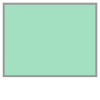

In [32]:
# Create external boundary of the shape that includes all three flightboxes
# site_roi_poly = site_polygon.unary_union.envelope
site_roi_poly = site_polygon.union_all().envelope

# Re-order vertices to counterclockwise
site_roi_poly = orient(site_roi_poly, sign=1.0)

# check site_roi_poly
site_roi_poly

Make a `GeoDataFrame` consisting of the bounding box geometry.

In [10]:
site_df = pd.DataFrame({"Name":["SOAP ROI Bounding Box"]})
site_bbox = gpd.GeoDataFrame({"Name":["SOAP ROI Bounding Box"], "geometry":[site_roi_poly]},crs="EPSG:4326")
site_bbox

,Name,geometry
0,SOAP ROI Bounding Box,"POLYGON ((-119.32506 36.98826, -119.17673 36.9..."


We can write this bounding box to a `geojson` file for use in future notebooks. This is commented out for now, but you can uncomment and run the cell below, if desired.

Next we can visualize our region of interest and the exterior boundary polygon containing ROIs. First add a function to help reformat bounding box coordinates to work with leaflet notation.

In [11]:
# Function to convert a bounding box for use in leaflet notation
def convert_bounds(bbox, invert_y=False):
    """
    Helper method for changing bounding box representation to leaflet notation

    ``(lon1, lat1, lon2, lat2) -> ((lat1, lon1), (lat2, lon2))``
    """
    x1, y1, x2, y2 = bbox
    if invert_y:
        y1, y2 = y2, y1
    return ((y1, x1), (y2, x2))

In [12]:
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Add Site Bounding Box
folium.GeoJson(site_bbox, name='bounding_box').add_to(map1)

# Add site roi geodataframe
site_polygon.explore("flightbxID",
                     popup=True,
                     categorical=True,
                     cmap='Set3',
                     style_kwds=dict(opacity=0.7, fillOpacity=0.4),
                     name="SOAP ROI",
                     m=map1)

map1.add_child(folium.LayerControl())
map1.fit_bounds(bounds=convert_bounds(site_polygon.unary_union.bounds))
display(fig)

Above we can see the SOAP flightbox, and the exterior boundary polygon containing the full area.

Lastly, we need to convert our polygon to a list of coordinate pairs, to create our Region of Interest (ROI).

In [13]:
# Set ROI as list of exterior polygon vertices as coordinate pairs
site_roi = list(site_roi_poly.exterior.coords)
site_roi

[(-119.3250598477851, 36.98825625902822),
 (-119.17673167047963, 36.98825625902822),
 (-119.17673167047963, 37.1042875313546),
 (-119.3250598477851, 37.1042875313546),
 (-119.3250598477851, 36.98825625902822)]

Finally we can look at the available NEON hyperspectral reflectance data over the site. NEON hyperspectral reflectance data are currently available under two different revisions, as AOP is in the process of implementing a BRDF (Bidirectional Reflectance Distribution Function), but this has not been applied to the full archive of data yet. These data are available under two revisions of the data product ID DP3.30006 - DP3.30006.001 are the directional surface reflectance, and DP3.30006.002 are the bidirectional (BRDF- and topographic- corrected) surface reflectance. Let's see what's available for each of these data products.

In [14]:
refl_rev1_dpid = 'DP3.30006.001'
refl_rev2_dpid = 'DP3.30006.002'
site = site_id

In [15]:
print(f'Directional Reflectance Data Available at NEON Site {site_id}:')
nu.list_available_dates(refl_rev1_dpid,site_id)

Directional Reflectance Data Available at NEON Site SOAP:


RELEASE-2025 Available Dates: 2013-06, 2017-07, 2018-06, 2019-06, 2021-07


In [16]:
print(f'Bidirectional Reflectance Data Available at NEON Site {site_id}:')
nu.list_available_dates(refl_rev2_dpid,site_id)

Bidirectional Reflectance Data Available at NEON Site SOAP:


PROVISIONAL Available Dates: 2023-06, 2023-07, 2024-06


```
print(f'Directional Reflectance Data Available at NEON Site {site_id}')
aop_dl.list_available_urls(refl_rev1_dpid,site)
```

```
print(f'Bidirectional Reflectance Data Available at NEON Site {site_id}')
aop_dl.list_available_urls(refl_rev2_dpid,site)
```

The bidirectional data for the 2nd 2023 and the 2024 visits of SOAP may have some overlap with EMIT data. The first SOAP visit in 2023 was reflown because it was not completely covered (due to poor weather conditions). Let's start with 2024 AOP data.

In [17]:
year = '2024'

We can download the reflectance data either using the neonutilities function `nu.by_file_aop`, which downloads all tiles for the entire site for a given year, or `nu.by_tile_aop`. To figure out the inputs of these functions, you can type `nu.by_tile_aop`, for example. 

AOP data are projected into a WGS84 coordinate system, with coordinates in UTM x, y. When using `nu.by_tile_aop` you need to specify the UTM easting and northing values for the tiles you want to download. If you're not sure the extent of the site, you can use the function `nu.get_aop_tile_extents`. Let's do that here, for the SOAP site collected in 2024. First set up your NEON token as follows, replacing the `"YOUR TOKEN HERE"` string with the token copied from the NEON "[My Account](https://data.neonscience.org/myaccount)" page. This will help speeed up downloads, and is strongly recommended (and will likely soon be required) for interacting with the NEON data via the API.

```
dotenv.set_key(dotenv_path=".env",
key_to_set="NEON_TOKEN",
value_to_set="YOUR TOKEN HERE")
```

In [18]:
soap2024_utm_extents = nu.get_aop_tile_extents(refl_rev2_dpid, site_id, year, token=os.environ.get("NEON_TOKEN"))

Easting Bounds: (292000, 306000)
Northing Bounds: (4094000, 4109000)


The AOP collection over SOAP in 2024 extends from 292000 - 306000 m (Easting) and 4094000 - 4109000 m (Northing. To display a list of the extents of every tile, you can print `soap2024_utm_extents`. 

Let's take a look at an RGB image of the SOAP site along with the Creek Fire boundary:

![png](./notebook_graphics/soap_proposed_study_area_rgb.png)

Here, the red polygon shows the approximate extent of the Creek Fire, the blue tiles represent the AOP reflectance data tile extents, and the tiles in green represent tiles in and out of the fire boundary that might be interesting to look at.

Let's go ahead and download 2 of these tiles to start (we will also show how to download the 9 tiles we are interested in):
You can specify the download path using the `savepath` variable. Let's set it to a data directory in line with the root directory where we're working, in this case we'll set it to `../../../data/NEON/refl`. 

The reflectance data are large in size (especially for an entire site's worth of data), so by default the download functions will display the expected download size and ask if you want to proceed with the download (y/n). The two reflectance tiles shown first are ~ 1.3 GB in size, and all nine tiles are 6 GB in size, so make sure you have enough space on your local disk before downloading. If you want to download without being prompted to continue, you can set the input variable `check_size=False`.

By default the files will be downloaded following the same structure that they are stored in on Google Cloud Storage. You can navigate through the `data/SOAP/NEON` folder, as additional metadata will be downloaded along with the 

In [19]:
# download 2 tiles in the bottom right corner of the green polygons
nu.by_tile_aop(dpid='DP3.30006.002',
               site=site_id,
               year=year,
               easting=[298005, 299005],
               northing=[4098005, 4098005],
               include_provisional=True,
               token=os.environ.get("NEON_TOKEN"),
               savepath='../../../data/SOAP/NEON')

Provisional NEON data are included. To exclude provisional data, use input parameter include_provisional=False.


Continuing will download 3 NEON data files totaling approximately 1.3 GB. Do you want to proceed? (y/n)  n


Download halted


You can either navigate to the download folder in File Explorer, or to programmatically see what files were downloaded, you can display the files as follows:

In [20]:
# see all files that were downloaded (including data, metadata, and READMEs):
for root, dirs, files in os.walk(r'..\..\..\data\SOAP\NEON'):
    for name in files:
        print(os.path.join(root, name))  # print file name

..\..\..\data\SOAP\NEON\DP3.30006.002\citation_DP3.30006.002_PROVISIONAL.txt
..\..\..\data\SOAP\NEON\DP3.30006.002\issueLog_DP3.30006.002.csv
..\..\..\data\SOAP\NEON\DP3.30006.002\neon-aop-provisional-products\2024\FullSite\D17\2024_SOAP_8\L3\Spectrometer\Reflectance\NEON_D17_SOAP_DP3_298000_4098000_bidirectional_reflectance.h5
..\..\..\data\SOAP\NEON\DP3.30006.002\neon-aop-provisional-products\2024\FullSite\D17\2024_SOAP_8\L3\Spectrometer\Reflectance\NEON_D17_SOAP_DP3_299000_4098000_bidirectional_reflectance.h5
..\..\..\data\SOAP\NEON\DP3.30006.002\neon-publication\NEON.DOM.SITE.DP3.30006.002\SOAP\20240601T000000--20240701T000000\basic\NEON.D17.SOAP.DP3.30006.002.readme.20250106T010033Z.txt


You can see there are several .txt and .csv files in addition to the .h5 data files. These include citation information: `citation_DP3.30006.002_PROVISIONAL.txt`, an issue log: `issueLog_DP3.30006.002.csv`, and a README: `NEON.D17.SOAP.DP3.30006.002.readme.20250106T010033Z.txt`. We encourage you to look through these files, particularly the issue log, which conveys information about issues and the resolution for the data product in question. Make sure there is not a known issue with the data you downloaded, especially since it is provisional.

If you only want to see the names of the .h5 reflectance data you downloaded, you can modify the code as follows:

In [21]:
# see only the .h5 files that were downloaded
for root, dirs, files in os.walk(r'..\..\..\data\SOAP\NEON'):
    for name in files:
        if name.endswith('.h5'):
            print(os.path.join(root, name))  # print file name

..\..\..\data\SOAP\NEON\DP3.30006.002\neon-aop-provisional-products\2024\FullSite\D17\2024_SOAP_8\L3\Spectrometer\Reflectance\NEON_D17_SOAP_DP3_298000_4098000_bidirectional_reflectance.h5
..\..\..\data\SOAP\NEON\DP3.30006.002\neon-aop-provisional-products\2024\FullSite\D17\2024_SOAP_8\L3\Spectrometer\Reflectance\NEON_D17_SOAP_DP3_299000_4098000_bidirectional_reflectance.h5


In [ ]:
Lastly, if you want to download all 9 AOP tiles that were highlighted, you can do so as follows:

In [ ]:
# download 9 tiles (in green)
nu.by_tile_aop(dpid=refl_rev2_dpid,
               site=site_id,
               year=year,
               easting=[297005, 297005, 297005, 298005, 298005, 298005, 299005, 299005, 299005],
               northing=[4098005, 4099005, 4100005, 4098005, 4099005, 4100005, 4098005, 4099005, 4100005],
               include_provisional=True,
               token=os.environ.get("NEON_TOKEN"),
               savepath='../../../data/SOAP/NEON')

Success! We've now downloaded two NEON bidirectional surface reflectance tiles into our data directory. Next, we will look for co-located EMIT data and download that as well.

### 2.2 Define EMIT Collections of Interest
We need to specify which products we want to search for. The best way to do this is using their concept-id. As mentioned above, we will conduct our search using the EMIT Level 2A Reflectance (EMITL2ARFL). We can do some quick collection queries using `earthaccess` to retrieve the concept-id for each dataset. 

### 2.3 NASA Earthdata Login Credentials

To download or stream NASA data you will need an Earthdata account, you can create one [here](https://urs.earthdata.nasa.gov/home). We will use the `login` function from the `earthaccess` library for authentication before downloading at the end of the notebook. This function can also be used to create a local `.netrc` file if it doesn't exist or add your login info to an existing `.netrc` file. If no Earthdata Login credentials are found in the `.netrc` you'll be prompted for them. This step is not necessary to conduct searches but is needed to download or stream data.

Let's start by creating some queries for the EMIT data collections of interest. For this project, we are interested in the EMIT L2A Reflectance data, and the L2B and L3 Mineral Maps. See the [EMIT Data Products Page](https://earth.jpl.nasa.gov/emit/data/data-products/) for more details on the EMIT data products.

In [22]:
# EMIT L2A Reflectance Collection Query
emit_l2a_refl_query = earthaccess.collection_query().keyword('EMIT L2A Reflectance')
emit_l2a_refl_query.fields(['ShortName','EntryTitle','Version']).get()

[{
   "meta": {
     "concept-id": "C2408750690-LPCLOUD",
     "granule-count": 150656,
     "provider-id": "LPCLOUD"
   },
   "umm": {
     "ShortName": "EMITL2ARFL",
     "EntryTitle": "EMIT L2A Estimated Surface Reflectance and Uncertainty and Masks 60 m V001",
     "Version": "001"
   }
 }]

We're also interested in the L2B "Mineralogy derived from fitting reflectance spectra" and L3 "Gridded map of mineral composition aggregated from level 2b with uncertainties and quality flags". The full descriptions of these data products are:
- EMIT L2B Estimated Mineral Identification and Band Depth and Uncertainty 60 m V001
- EMIT L3 Aggregated Mineral Spectral Abundance

In [23]:
# EMIT L2B Collection Query
emit_l2b_query = earthaccess.collection_query().keyword('EMIT L2B Estimated Mineral Identification')
emit_l2b_query.fields(['ShortName','EntryTitle','Version']).get()

[{
   "meta": {
     "concept-id": "C2408034484-LPCLOUD",
     "granule-count": 150648,
     "provider-id": "LPCLOUD"
   },
   "umm": {
     "ShortName": "EMITL2BMIN",
     "EntryTitle": "EMIT L2B Estimated Mineral Identification and Band Depth and Uncertainty 60 m V001",
     "Version": "001"
   }
 },
 {
   "meta": {
     "concept-id": "C2748088093-LPCLOUD",
     "granule-count": 1574,
     "provider-id": "LPCLOUD"
   },
   "umm": {
     "ShortName": "EMITL2BCH4PLM",
     "EntryTitle": "EMIT L2B Estimated Methane Plume Complexes 60 m V001",
     "Version": "001"
   }
 },
 {
   "meta": {
     "concept-id": "C2867824144-LPCLOUD",
     "granule-count": 173,
     "provider-id": "LPCLOUD"
   },
   "umm": {
     "ShortName": "EMITL2BCO2PLM",
     "EntryTitle": "EMIT L2B Estimated Carbon Dioxide Plume Complexes 60 m V001",
     "Version": "001"
   }
 },
 {
   "meta": {
     "concept-id": "C2408752948-LPCLOUD",
     "granule-count": 1,
     "provider-id": "LPCLOUD"
   },
   "umm": {
     "Sho

This showed both the mineral maps (L2B and L3). The concept IDs for those are:
EMIT L2B Estimated Mineral Identification and Band Depth and Uncertainty 60 m V001 (EMITL2BMIN): 'C2408034484-LPCLOUD'
EMIT L3 Aggregated Mineral Spectral Abundance and Uncertainty 0.5 Deg V001 (EMITL3ASA): 'C2408752948-LPCLOUD'

If your search returns multiple products, be sure to select the right concept-id. Create a list of these concept-ids for our data search.

In [24]:
# Data Collections for our search
emit_l2a_refl_concept_id = ['C2408750690-LPCLOUD'] #L2A reflectance
emit_l2b_mibd_concept_id = ['C2408034484-LPCLOUD'] #L2B mineral identification and band depth
emit_l3_amsa_concept_id = ['C2408752948-LPCLOUD'] #L3 aggregated mineral spectral abundance and uncertainty

### 2.3 Define Date Range

For our date range, we'll look at data collected between January 2022 and October 2023. The `date_range` can be specified as a pair of dates, start and end (up to, not including).

In [25]:
# Define Date Range
date_range = ('2022-01-01','2024-11-01')

### 2.4 Searching

Submit a query to find the L2A Reflectance data using `earthaccess`, setting the `site_roi` as the region of interest.

In [26]:
emit_l2a_refl_query_results = earthaccess.search_data(
    concept_id=emit_l2a_refl_concept_id,
    polygon=site_roi,
    temporal=date_range,
    count=500)

Granules found: 23


Make a similar query for the L2B Mineral Identification data product:

In [27]:
emit_l2b_mibd_query_results = earthaccess.search_data(
    concept_id=emit_l2b_mibd_concept_id,
    polygon=site_roi,
    temporal=date_range,
    count=500)

Granules found: 23


And lastly, query the L3 Aggregated Mineral data product:

In [28]:
emit_l3_amsa_query_results = earthaccess.search_data(
    concept_id=emit_l3_amsa_concept_id,
    polygon=site_roi,
    temporal=date_range,
    count=500)

Granules found: 1


Only one granule was found for the aggregated L3 mineral map data product. This is probably because the "aggregation" piece aggregates over all time periods to come up with a single map. Need to confirm this!


## 3. Organizing and Filtering Results

As we can see from above, the results objects (e.g. `emit_l2a_refl_query_results`) contain a list of objects with metadata and links. We can convert this to a more readable format, a dataframe. In addition, we can make it a geodataframe by taking the spatial metadata and creating a shapely polygon representing the spatial coverage, and further customize which information we want to use from other metadata fields.

First, we define some functions to help us create a shapely object for our geodataframe, and retrieve the specific browse image URLs that we want. By default, the browse image selected by `earthaccess` is the first one in the list, but the ECO_L2_LSTE has several browse images, and we want to make sure we retrieve the `png` file, which is a preview of the LSTE.

In [29]:
# Function to create shapely polygon of spatial coverage
def get_shapely_object(result:earthaccess.results.DataGranule):
    # Get Geometry Keys
    geo = result['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']
    keys = geo.keys()

    if 'BoundingRectangles' in keys:
        bounding_rectangle = geo['BoundingRectangles'][0]
        # Create bbox tuple
        bbox_coords = (bounding_rectangle['WestBoundingCoordinate'],bounding_rectangle['SouthBoundingCoordinate'],
                    bounding_rectangle['EastBoundingCoordinate'],bounding_rectangle['NorthBoundingCoordinate'])
        # Create shapely geometry from bbox
        shape = geometry.box(*bbox_coords, ccw=True)
    elif 'GPolygons' in keys:
        points = geo['GPolygons'][0]['Boundary']['Points']
        # Create shapely geometry from polygons
        shape = geometry.Polygon([[p['Longitude'],p['Latitude']] for p in points])
    else:
         raise ValueError('Provided result does not contain bounding boxes/polygons or is incompatible.')
    return(shape)

# Retrieve png browse image if it exists or first jpg in list of urls
def get_png(result:earthaccess.results.DataGranule):
    https_links = [link for link in result.dataviz_links() if 'https' in link]
    if len(https_links) == 1:
        browse = https_links[0]
    elif len(https_links) == 0:
        browse = 'no browse image'
        warnings.warn(f"There is no browse imagery for {result['umm']['GranuleUR']}.")
    else:
        browse = [png for png in https_links if '.png' in png][0]
    return(browse)

Now that we have our functions we can create a dataframe, then calculate and add our shapely geometries to make a geodataframe. After that, add a column for our browse image urls and print the number of granules in our results, so we can monitor the quantity we  are working with a we winnow down to the data we want.

In [30]:
# Create Dataframe of Results Metadata
emit_l2a_refl_results_df = pd.json_normalize(emit_l2a_refl_query_results)
# Create shapely polygons for result
geometries = [get_shapely_object(emit_l2a_refl_query_results[index]) for index in emit_l2a_refl_results_df.index.to_list()]
# Convert to GeoDataframe
emit_l2a_refl_gdf = gpd.GeoDataFrame(emit_l2a_refl_results_df, geometry=geometries, crs="EPSG:4326")
# Remove emit_results_df, no longer needed
del emit_l2a_refl_results_df
# Add browse imagery links
emit_l2a_refl_gdf['browse'] = [get_png(granule) for granule in emit_l2a_refl_query_results]
emit_l2a_refl_gdf['shortname'] = [result['umm']['CollectionReference']['ShortName'] for result in emit_l2a_refl_query_results]
# Preview GeoDataframe
print(f'{emit_l2a_refl_gdf.shape[0]} granules total')

23 granules total


Optionally preview the geodataframe to get an idea what it looks like.

In [ ]:
#emit_l2a_refl_gdf.head()

There are a lot of columns with data that is not relevant for this exercise, so we can drop those. To do that, first list the names of columns.

In [31]:
# List Column Names
emit_l2a_refl_gdf.columns

Index(['size', 'meta.concept-type', 'meta.concept-id', 'meta.revision-id',
       'meta.native-id', 'meta.collection-concept-id', 'meta.provider-id',
       'meta.format', 'meta.revision-date',
       'umm.TemporalExtent.RangeDateTime.BeginningDateTime',
       'umm.TemporalExtent.RangeDateTime.EndingDateTime', 'umm.GranuleUR',
       'umm.AdditionalAttributes',
       'umm.SpatialExtent.HorizontalSpatialDomain.Geometry.GPolygons',
       'umm.ProviderDates', 'umm.CollectionReference.ShortName',
       'umm.CollectionReference.Version', 'umm.PGEVersionClass.PGEName',
       'umm.PGEVersionClass.PGEVersion', 'umm.RelatedUrls', 'umm.CloudCover',
       'umm.DataGranule.DayNightFlag',
       'umm.DataGranule.ArchiveAndDistributionInformation',
       'umm.DataGranule.ProductionDateTime', 'umm.Platforms',
       'umm.MetadataSpecification.URL', 'umm.MetadataSpecification.Name',
       'umm.MetadataSpecification.Version', 'geometry', 'browse', 'shortname'],
      dtype='object')

Now create a list of columns to keep and use it to filter the dataframe.

In [32]:
# Create a list of columns to keep
keep_cols = ['meta.concept-id','meta.native-id', 'umm.TemporalExtent.RangeDateTime.BeginningDateTime','umm.TemporalExtent.RangeDateTime.EndingDateTime','umm.CloudCover','umm.DataGranule.DayNightFlag','geometry','browse', 'shortname']
# Remove unneeded columns
emit_l2a_refl_gdf = emit_l2a_refl_gdf[emit_l2a_refl_gdf.columns.intersection(keep_cols)]
emit_l2a_refl_gdf.head()

,meta.concept-id,meta.native-id,umm.TemporalExtent.RangeDateTime.BeginningDateTime,umm.TemporalExtent.RangeDateTime.EndingDateTime,umm.CloudCover,umm.DataGranule.DayNightFlag,geometry,browse,shortname
0,G2597030211-LPCLOUD,EMIT_L2A_RFL_001_20220813T232430_2222515_007,2022-08-13T23:24:30Z,2022-08-13T23:24:42Z,9,Day,"POLYGON ((-119.46864 37.47018, -119.92542 36.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
1,G2597513939-LPCLOUD,EMIT_L2A_RFL_001_20220817T214650_2222914_007,2022-08-17T21:46:50Z,2022-08-17T21:47:02Z,93,Day,"POLYGON ((-119.68089 38.26041, -120.12322 37.6...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
2,G2658516156-LPCLOUD,EMIT_L2A_RFL_001_20230415T222408_2310515_006,2023-04-15T22:24:08Z,2023-04-15T22:24:20Z,23,Day,"POLYGON ((-119.72453 37.86227, -120.18778 37.2...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
3,G2658516087-LPCLOUD,EMIT_L2A_RFL_001_20230415T222420_2310515_007,2023-04-15T22:24:20Z,2023-04-15T22:24:32Z,27,Day,"POLYGON ((-119.02840 37.37526, -119.49146 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
4,G2738554768-LPCLOUD,EMIT_L2A_RFL_001_20230608T175820_2315912_004,2023-06-08T17:58:20Z,2023-06-08T17:58:32Z,47,Day,"POLYGON ((-119.63505 37.57834, -120.48850 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL


This is looking better, but we can make it more readable by renaming our columns.

In [33]:
# Rename some columns to improve readability
emit_l2a_refl_gdf.rename(columns = {'meta.concept-id':'concept_id','meta.native-id':'granule',
                           'umm.TemporalExtent.RangeDateTime.BeginningDateTime':'start_datetime',
                           'umm.TemporalExtent.RangeDateTime.EndingDateTime':'end_datetime',
                           'umm.CloudCover':'cloud_cover',
                           'umm.DataGranule.DayNightFlag':'day_night'}, inplace=True)
print('# of scenes:',len(emit_l2a_refl_gdf))
# display the geodataframe
emit_l2a_refl_gdf

# of scenes: 23


,concept_id,granule,start_datetime,end_datetime,cloud_cover,day_night,geometry,browse,shortname
0,G2597030211-LPCLOUD,EMIT_L2A_RFL_001_20220813T232430_2222515_007,2022-08-13T23:24:30Z,2022-08-13T23:24:42Z,9,Day,"POLYGON ((-119.46864 37.47018, -119.92542 36.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
1,G2597513939-LPCLOUD,EMIT_L2A_RFL_001_20220817T214650_2222914_007,2022-08-17T21:46:50Z,2022-08-17T21:47:02Z,93,Day,"POLYGON ((-119.68089 38.26041, -120.12322 37.6...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
2,G2658516156-LPCLOUD,EMIT_L2A_RFL_001_20230415T222408_2310515_006,2023-04-15T22:24:08Z,2023-04-15T22:24:20Z,23,Day,"POLYGON ((-119.72453 37.86227, -120.18778 37.2...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
3,G2658516087-LPCLOUD,EMIT_L2A_RFL_001_20230415T222420_2310515_007,2023-04-15T22:24:20Z,2023-04-15T22:24:32Z,27,Day,"POLYGON ((-119.02840 37.37526, -119.49146 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
4,G2738554768-LPCLOUD,EMIT_L2A_RFL_001_20230608T175820_2315912_004,2023-06-08T17:58:20Z,2023-06-08T17:58:32Z,47,Day,"POLYGON ((-119.63505 37.57834, -120.48850 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
5,G2738554498-LPCLOUD,EMIT_L2A_RFL_001_20230608T175832_2315912_005,2023-06-08T17:58:32Z,2023-06-08T17:58:43Z,88,Day,"POLYGON ((-118.92422 38.06072, -119.79446 37.4...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
6,G2736728172-LPCLOUD,EMIT_L2A_RFL_001_20230622T193237_2317313_006,2023-06-22T19:32:37Z,2023-06-22T19:32:49Z,8,Day,"POLYGON ((-119.43843 37.42319, -119.89761 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
7,G2737583843-LPCLOUD,EMIT_L2A_RFL_001_20230626T175417_2317712_006,2023-06-26T17:54:17Z,2023-06-26T17:54:29Z,55,Day,"POLYGON ((-119.61971 38.27853, -120.06863 37.6...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
8,G2737583846-LPCLOUD,EMIT_L2A_RFL_001_20230626T175429_2317712_007,2023-06-26T17:54:29Z,2023-06-26T17:54:40Z,53,Day,"POLYGON ((-118.90848 37.79703, -119.36272 37.1...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL
9,G2743397410-LPCLOUD,EMIT_L2A_RFL_001_20230731T205320_2321214_004,2023-07-31T20:53:20Z,2023-07-31T20:53:32Z,5,Day,"POLYGON ((-119.12272 37.51724, -119.97849 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL


> **Note: If querying on-premises (not cloud) LP DAAC datasets, the `meta.concept-id` will not show as `xxxxxx-LPCLOUD`. For these datasets, the granule name can be retrieved from the `umm.DataGranule.Identifiers` column.**

In [34]:
#emit_gdf['datetime_obj'] = pd.to_datetime(emit_gdf['start_datetime']) # 2i2c
emit_l2a_refl_gdf['datetime_obj'] = pd.to_datetime(emit_l2a_refl_gdf['start_datetime'], format='ISO8601') # Local ENV

Our first step toward filtering the datasets will be to add a column with a `datetime`. 

> **You may have noticed that the date format is similar for ECOSTRESS and EMIT, but the ECOSTRESS data also includes fractional seconds. If working locally using `lpdaac_vitals` python environment, you may need to pass the `format='ISO8601'`argument to the `to_datetime` function, as shown in the commented-out line due to a difference in versions of pandas.**

We can filter using the day/night flag as well, since we need a daytime collection to be comparable to the NEON data (which is captured at a high solar angle). This is not as necessary for now.

In [ ]:
# emit_l2a_refl_gdf = emit_l2a_refl_gdf[emit_gdf['day_night'].str.contains('Day')]

You can also filter by cloud cover. Let's start by removing any collections with > 50% cloud cover

In [35]:
emit_l2a_refl_gdf_clear = emit_l2a_refl_gdf[emit_l2a_refl_gdf['cloud_cover'] < 50]
print('# of scenes with < 50% cloud cover:',len(emit_l2a_refl_gdf_clear))
emit_l2a_refl_gdf_clear

# of scenes with < 50% cloud cover: 13


,concept_id,granule,start_datetime,end_datetime,cloud_cover,day_night,geometry,browse,shortname,datetime_obj
0,G2597030211-LPCLOUD,EMIT_L2A_RFL_001_20220813T232430_2222515_007,2022-08-13T23:24:30Z,2022-08-13T23:24:42Z,9,Day,"POLYGON ((-119.46864 37.47018, -119.92542 36.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2022-08-13 23:24:30+00:00
2,G2658516156-LPCLOUD,EMIT_L2A_RFL_001_20230415T222408_2310515_006,2023-04-15T22:24:08Z,2023-04-15T22:24:20Z,23,Day,"POLYGON ((-119.72453 37.86227, -120.18778 37.2...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-04-15 22:24:08+00:00
3,G2658516087-LPCLOUD,EMIT_L2A_RFL_001_20230415T222420_2310515_007,2023-04-15T22:24:20Z,2023-04-15T22:24:32Z,27,Day,"POLYGON ((-119.02840 37.37526, -119.49146 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-04-15 22:24:20+00:00
4,G2738554768-LPCLOUD,EMIT_L2A_RFL_001_20230608T175820_2315912_004,2023-06-08T17:58:20Z,2023-06-08T17:58:32Z,47,Day,"POLYGON ((-119.63505 37.57834, -120.48850 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-06-08 17:58:20+00:00
6,G2736728172-LPCLOUD,EMIT_L2A_RFL_001_20230622T193237_2317313_006,2023-06-22T19:32:37Z,2023-06-22T19:32:49Z,8,Day,"POLYGON ((-119.43843 37.42319, -119.89761 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-06-22 19:32:37+00:00
9,G2743397410-LPCLOUD,EMIT_L2A_RFL_001_20230731T205320_2321214_004,2023-07-31T20:53:20Z,2023-07-31T20:53:32Z,5,Day,"POLYGON ((-119.12272 37.51724, -119.97849 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-07-31 20:53:20+00:00
10,G2759644643-LPCLOUD,EMIT_L2A_RFL_001_20230826T175001_2323812_003,2023-08-26T17:50:01Z,2023-08-26T17:50:13Z,8,Day,"POLYGON ((-119.83958 37.67923, -120.30956 37.0...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-08-26 17:50:01+00:00
11,G2759650982-LPCLOUD,EMIT_L2A_RFL_001_20230826T175013_2323812_004,2023-08-26T17:50:13Z,2023-08-26T17:50:25Z,7,Day,"POLYGON ((-119.13836 37.19188, -119.61771 36.5...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-08-26 17:50:13+00:00
17,G3086912246-LPCLOUD,EMIT_L2A_RFL_001_20240610T231454_2416215_019,2024-06-10T23:14:54Z,2024-06-10T23:15:06Z,45,Day,"POLYGON ((-119.22767 37.80900, -119.68539 37.1...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2024-06-10 23:14:54+00:00
18,G3173971544-LPCLOUD,EMIT_L2A_RFL_001_20240723T230730_2420515_004,2024-07-23T23:07:30Z,2024-07-23T23:07:42Z,36,Day,"POLYGON ((-119.46613 37.59595, -120.32439 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2024-07-23 23:07:30+00:00


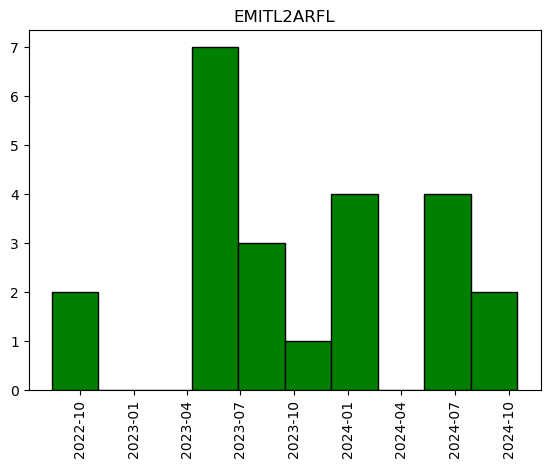

In [36]:
emit_l2a_refl_gdf.hist(column='datetime_obj', by='shortname', bins=10, color='green', edgecolor='black', linewidth=1, sharey=True);


## 4. Visualizing Intersecting Coverage

Now that we have geodataframes containing some co-located data, we can visualize them on a map using `folium`. It's often difficult to visualize a large time-series of scenes, so we've included an example in Appendix A1 on how to filter to a single day.

In [37]:
# Plot Using Folium
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Add Site Bounding Box
folium.GeoJson(site_bbox,
                name='bounding_box',).add_to(map1)

# Add roi geodataframe
site_polygon.explore("flightbxID",
                      popup=True,
                      categorical=True,
                      cmap='Set3',
                      style_kwds=dict(opacity=0.7, fillOpacity=0.4),
                      name="SOAP ROI",
                      m=map1)

# Plot STAC EMITL2ARFL Results - note we must drop the datetime_obj columns for this to work
emit_l2a_refl_gdf_clear.drop(columns=['datetime_obj']).explore(
    "granule",
    categorical=True,
    tooltip=[
        "granule",
        "start_datetime",
        "cloud_cover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

map1.fit_bounds(bounds=convert_bounds(emit_l2a_refl_gdf.unary_union.bounds))
map1.add_child(folium.LayerControl())
display(fig)

### 4.2 Previewing EMIT Browse Imagery
The EMIT browse imagery is not orthorectified, so to get an idea what scenes look like, we can plot them in a grid using matplotlib.

> Note: The black space is indicative of onboard cloud masking that occurs before data is downlinked from the ISS.

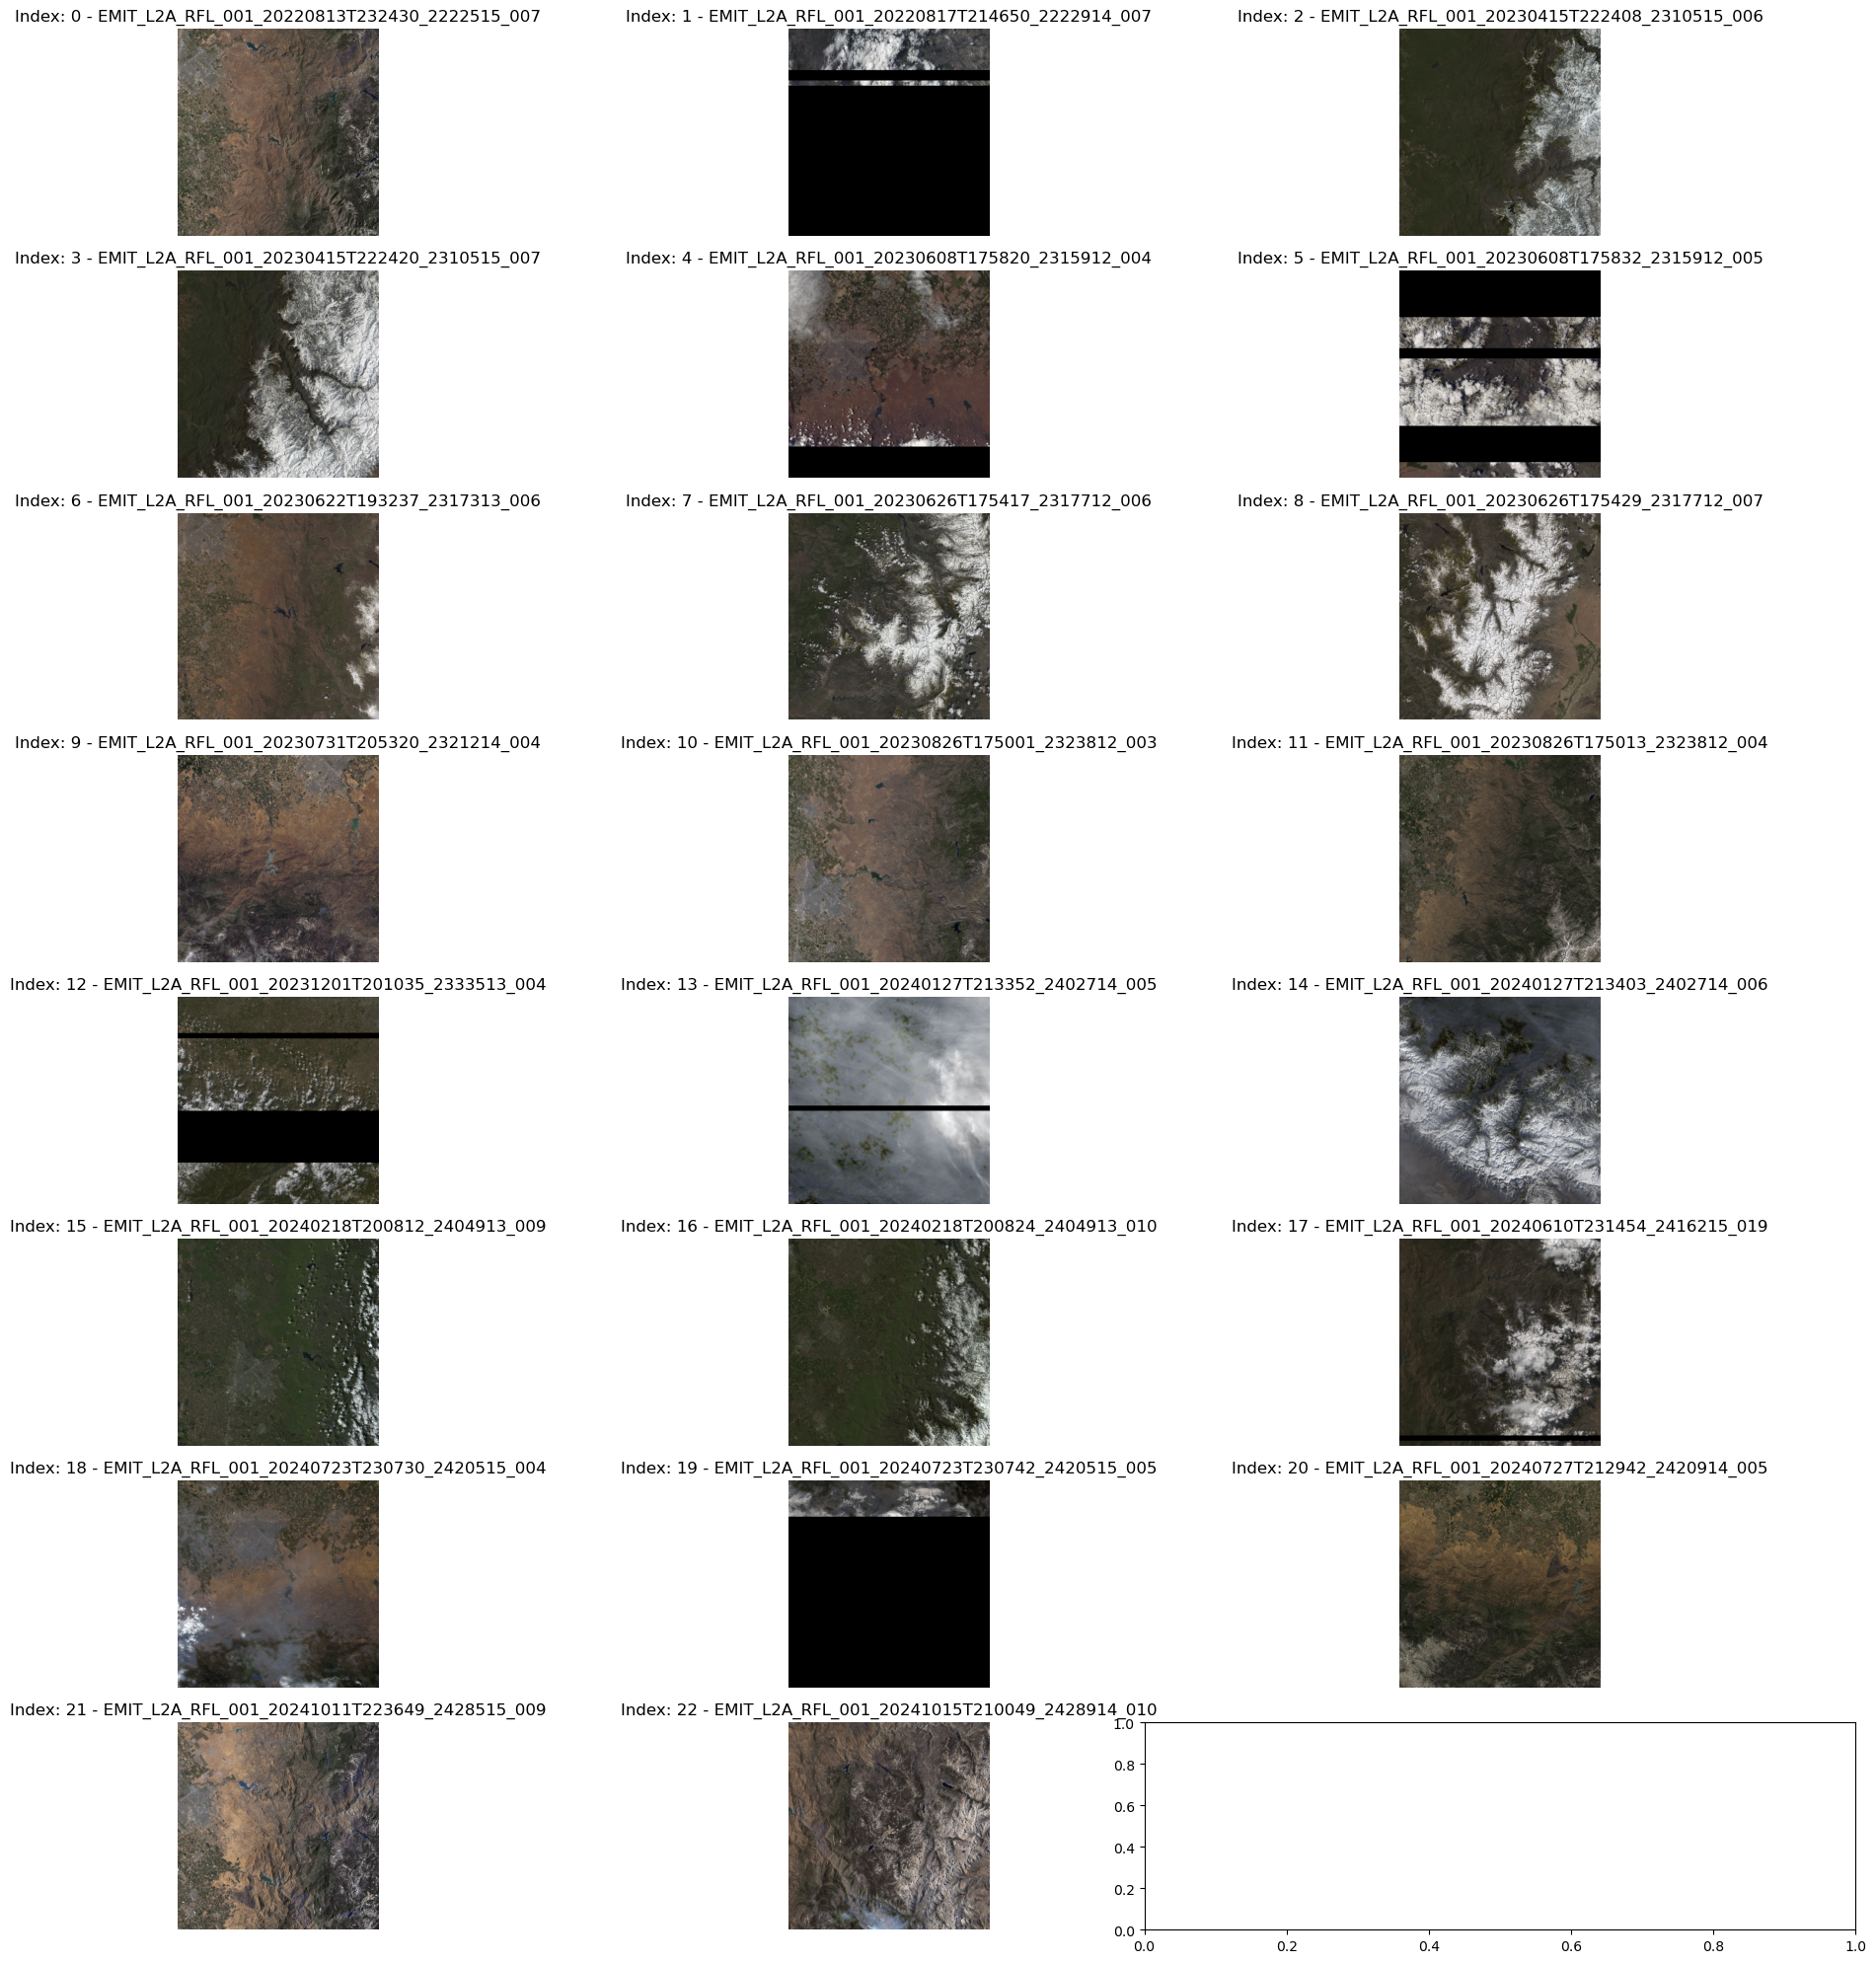

In [38]:
cols = 3
rows = math.ceil(len(emit_l2a_refl_gdf)/cols)
fig, ax = plt.subplots(rows, cols, figsize=(20,20))
ax = ax.flatten()

for _n, index in enumerate(emit_l2a_refl_gdf.index.to_list()):
    img = io.imread(emit_l2a_refl_gdf['browse'][index])
    ax[_n].imshow(img)
    ax[_n].set_title(f"Index: {index} - {emit_l2a_refl_gdf['granule'][index]}")
    ax[_n].axis('off')
plt.tight_layout()
plt.show()

### 4.3 Further Filtering

We can see that some of these granules likely won't work because of the large amount of cloud cover, we can use a list of these to filter them out. Make a list of indexes to filter out.

In [40]:
# set a stricter threshold for cloud cover and filter to remove scenes with > 30% cloud cover
# note that it's possible that the portion of the EMIT scene which is cloudy does not overlap with the SOAP site, 
# so this is just a rough way to filter out cloudy data
# to be safe, it's best to look at the scenes first before eliminating!
emit_l2a_refl_gdf_clear = emit_l2a_refl_gdf[emit_l2a_refl_gdf.cloud_cover < 30]
print('# of scenes with < 30% cloud cover:',len(emit_l2a_refl_gdf_clear))
emit_l2a_refl_gdf_clear

# of scenes with < 30% cloud cover: 10


,concept_id,granule,start_datetime,end_datetime,cloud_cover,day_night,geometry,browse,shortname,datetime_obj
0,G2597030211-LPCLOUD,EMIT_L2A_RFL_001_20220813T232430_2222515_007,2022-08-13T23:24:30Z,2022-08-13T23:24:42Z,9,Day,"POLYGON ((-119.46864 37.47018, -119.92542 36.8...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2022-08-13 23:24:30+00:00
2,G2658516156-LPCLOUD,EMIT_L2A_RFL_001_20230415T222408_2310515_006,2023-04-15T22:24:08Z,2023-04-15T22:24:20Z,23,Day,"POLYGON ((-119.72453 37.86227, -120.18778 37.2...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-04-15 22:24:08+00:00
3,G2658516087-LPCLOUD,EMIT_L2A_RFL_001_20230415T222420_2310515_007,2023-04-15T22:24:20Z,2023-04-15T22:24:32Z,27,Day,"POLYGON ((-119.02840 37.37526, -119.49146 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-04-15 22:24:20+00:00
6,G2736728172-LPCLOUD,EMIT_L2A_RFL_001_20230622T193237_2317313_006,2023-06-22T19:32:37Z,2023-06-22T19:32:49Z,8,Day,"POLYGON ((-119.43843 37.42319, -119.89761 36.7...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-06-22 19:32:37+00:00
9,G2743397410-LPCLOUD,EMIT_L2A_RFL_001_20230731T205320_2321214_004,2023-07-31T20:53:20Z,2023-07-31T20:53:32Z,5,Day,"POLYGON ((-119.12272 37.51724, -119.97849 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-07-31 20:53:20+00:00
10,G2759644643-LPCLOUD,EMIT_L2A_RFL_001_20230826T175001_2323812_003,2023-08-26T17:50:01Z,2023-08-26T17:50:13Z,8,Day,"POLYGON ((-119.83958 37.67923, -120.30956 37.0...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-08-26 17:50:01+00:00
11,G2759650982-LPCLOUD,EMIT_L2A_RFL_001_20230826T175013_2323812_004,2023-08-26T17:50:13Z,2023-08-26T17:50:25Z,7,Day,"POLYGON ((-119.13836 37.19188, -119.61771 36.5...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2023-08-26 17:50:13+00:00
20,G3177327289-LPCLOUD,EMIT_L2A_RFL_001_20240727T212942_2420914_005,2024-07-27T21:29:42Z,2024-07-27T21:29:53Z,3,Day,"POLYGON ((-118.87672 37.27332, -119.72562 36.6...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2024-07-27 21:29:42+00:00
21,G3265882496-LPCLOUD,EMIT_L2A_RFL_001_20241011T223649_2428515_009,2024-10-11T22:36:49Z,2024-10-11T22:37:01Z,9,Day,"POLYGON ((-119.59810 37.60208, -120.05849 36.9...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2024-10-11 22:36:49+00:00
22,G3279486184-LPCLOUD,EMIT_L2A_RFL_001_20241015T210049_2428914_010,2024-10-15T21:00:49Z,2024-10-15T21:01:01Z,16,Day,"POLYGON ((-119.14209 37.70631, -119.59476 37.0...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,2024-10-15 21:00:49+00:00


Filter out the bad granules.

We can see that there are 10 scenes with low (< 30%) cloud cover. 

Let's take a look at a couple of the most promising options, in terms of low cloud-cover and dates that most closely align with the AOP collections in 2022 and 2023. Our best prospects are:

June 22, 2023 (8% cloud cover)

- **6**: `EMIT_L2A_RFL_001_20230622T193237_2317313_006`

July 31, 2023 (5% cloud cover)

- **9**: `EMIT_L2A_RFL_001_20230731T205320_2321214_004`

Or, possibly

July 27, 2024 (3% cloud cover, Index 20):

- **20**: `EMIT_L2A_RFL_001_20240727T212942_2420914_005`

Let's start by plotting the July 31, 2023 scene (index 9) as follows:

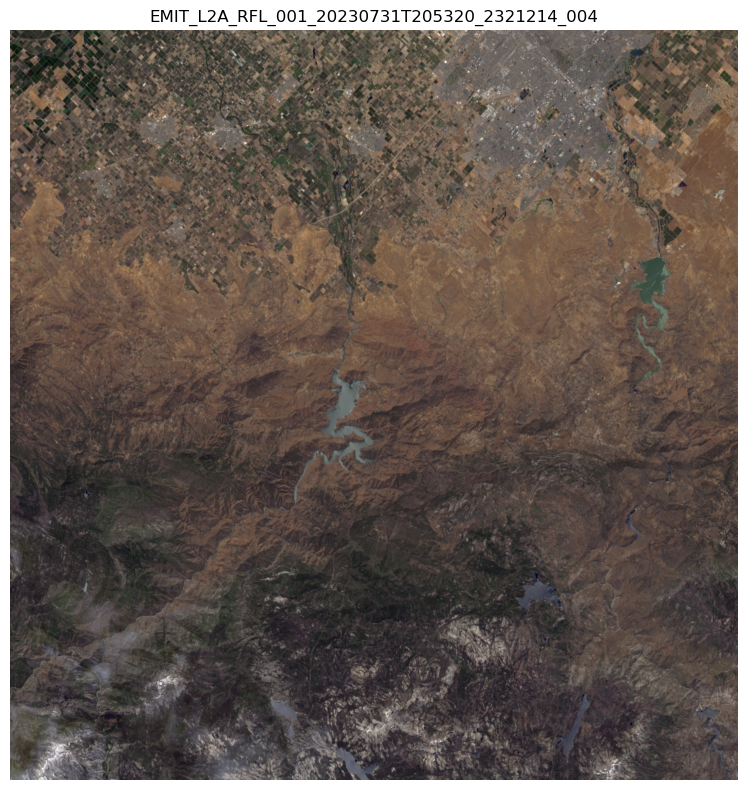

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(8,8))
img = io.imread(emit_l2a_refl_gdf['browse'][9])
ax.imshow(img)
ax.set_title(f"{emit_l2a_refl_gdf['granule'][9]}")
ax.axis('off')
plt.tight_layout()
plt.show()

**We can now go back to our `folium` plot above and  re-run the cell to update it based on our filtering.**

In [42]:
emit_l2a_refl_gdf_july_2023 = emit_l2a_refl_gdf[emit_l2a_refl_gdf['granule'] == 'EMIT_L2A_RFL_001_20230731T205320_2321214_004']

In [43]:
# Plot Using Folium
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Add the Site Bounding Box
folium.GeoJson(site_bbox,
                name='bounding_box',
                ).add_to(map1)

# Add roi geodataframe
site_polygon.explore("flightbxID",
                      popup=True,
                      categorical=True,
                      cmap='Set3',
                      style_kwds=dict(opacity=0.7, fillOpacity=0.4),
                      name="SOAP ROI",
                      m=map1)

# Plot STAC EMITL2ARFL Results - note we must drop the datetime_obj columns for this to work
emit_l2a_refl_gdf_july_2023.drop(columns=['datetime_obj']).explore(
    "granule",
    categorical=True,
    tooltip=[
        "granule",
        "start_datetime",
        "cloud_cover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

map1.fit_bounds(bounds=convert_bounds(emit_l2a_refl_gdf.unary_union.bounds))
map1.add_child(folium.LayerControl())
display(fig)

In [44]:
emit_l2a_refl_gdf_june_2023 = emit_l2a_refl_gdf[emit_l2a_refl_gdf['granule'] == 'EMIT_L2A_RFL_001_20230622T193237_2317313_006']

# Plot Using Folium
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Add the Site Bounding Box
folium.GeoJson(site_bbox,
                name='bounding_box',
                ).add_to(map1)

# Add roi geodataframe
site_polygon.explore("flightbxID",
                      popup=True,
                      categorical=True,
                      cmap='Set3',
                      style_kwds=dict(opacity=0.7, fillOpacity=0.4),
                      name="SOAP ROI",
                      m=map1)

# Plot STAC EMITL2ARFL Results - note we must drop the datetime_obj columns for this to work
emit_l2a_refl_gdf_june_2023.drop(columns=['datetime_obj']).explore(
    "granule",
    categorical=True,
    tooltip=[
        "granule",
        "start_datetime",
        "cloud_cover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

map1.fit_bounds(bounds=convert_bounds(emit_l2a_refl_gdf.unary_union.bounds))
map1.add_child(folium.LayerControl())
display(fig)

In [45]:
emit_l2a_refl_gdf_july_2024 = emit_l2a_refl_gdf[emit_l2a_refl_gdf['granule'] == 'EMIT_L2A_RFL_001_20240727T212942_2420914_005']

# Plot Using Folium
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Add the Site Bounding Box
folium.GeoJson(site_bbox,
                name='bounding_box',
                ).add_to(map1)

# Add roi geodataframe
site_polygon.explore("flightbxID",
                      popup=True,
                      categorical=True,
                      cmap='Set3',
                      style_kwds=dict(opacity=0.7, fillOpacity=0.4),
                      name="SOAP ROI",
                      m=map1)

# Plot STAC EMITL2ARFL Results - note we must drop the datetime_obj columns for this to work
emit_l2a_refl_gdf_july_2024.drop(columns=['datetime_obj']).explore(
    "granule",
    categorical=True,
    tooltip=[
        "granule",
        "start_datetime",
        "cloud_cover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

map1.fit_bounds(bounds=convert_bounds(emit_l2a_refl_gdf.unary_union.bounds))
map1.add_child(folium.LayerControl())
display(fig)

The overlap is not great on July 2024, so this won't be as useful for us. Note that the EMIT overlap looks for any overlap, not fully encompassing, so it's important to check the overlap of individual granueles for this reason.

## 5. Generating a list of URLs and downloading data

Creating a list of results URLs will include all of these assets, so if we only want a subset we need an additional filter to keep the specific assets we want.

If you look back, you can see we kept the same indexing throughout the notebook. This enables us to simply subset the `earthaccess` results object to retrieve the results we want. 

Create a list of index values to keep. Let's look at the original `emit_l2a_refl_query_results` to start:

In [46]:
emit_l2a_refl_query_results

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -119.46864318847656, 'Latitude': 37.470184326171875}, {'Longitude': -119.9254150390625, 'Latitude': 36.824989318847656}, {'Longitude': -119.16255187988281, 'Latitude': 36.284912109375}, {'Longitude': -118.70578002929688, 'Latitude': 36.93010711669922}, {'Longitude': -119.46864318847656, 'Latitude': 37.470184326171875}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-08-13T23:24:30Z', 'EndingDateTime': '2022-08-13T23:24:42Z'}}
 Size(MB): 3580.81951713562
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20220813T232430_2222515_007/EMIT_L2A_RFL_001_20220813T232430_2222515_007.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20220813T232430_2222515_007/EMIT_L2A_RFLUNCERT_001_20220813T232430_22

Let's download the data from July 2023, Index 9:

In [47]:
keep_granules = [9]

Filter the results list.

In [48]:
filtered_refl = [result for i, result in enumerate(emit_l2a_refl_query_results) if i in keep_granules]
filtered_refl

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -119.12271881103516, 'Latitude': 37.517242431640625}, {'Longitude': -119.9784927368164, 'Latitude': 36.912025451660156}, {'Longitude': -119.51526641845703, 'Latitude': 36.25703430175781}, {'Longitude': -118.65949249267578, 'Latitude': 36.86225128173828}, {'Longitude': -119.12271881103516, 'Latitude': 37.517242431640625}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-07-31T20:53:20Z', 'EndingDateTime': '2023-07-31T20:53:32Z'}}
 Size(MB): 3580.296537399292
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20230731T205320_2321214_004/EMIT_L2A_RFL_001_20230731T205320_2321214_004.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20230731T205320_2321214_004/EMIT_L2A_RFLUNCERT_001_20230731T205320

We can also find the L2 Mineral products similarly. Since the mineral data product is derived from the reflectance, we can just select the same granule as we did with the reflectance data. Double check that the date of the image (2024-07-27) is the same!

In [49]:
filtered_mibd = [result for i, result in enumerate(emit_l2b_mibd_query_results) if i in keep_granules]
filtered_mibd

[Collection: {'ShortName': 'EMITL2BMIN', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -119.12271881103516, 'Latitude': 37.517242431640625}, {'Longitude': -119.9784927368164, 'Latitude': 36.912025451660156}, {'Longitude': -119.51526641845703, 'Latitude': 36.25703430175781}, {'Longitude': -118.65949249267578, 'Latitude': 36.86225128173828}, {'Longitude': -119.12271881103516, 'Latitude': 37.517242431640625}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-07-31T20:53:20Z', 'EndingDateTime': '2023-07-31T20:53:32Z'}}
 Size(MB): 87.36373138427734
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BMIN.001/EMIT_L2B_MIN_001_20230731T205320_2321214_004/EMIT_L2B_MIN_001_20230731T205320_2321214_004.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BMIN.001/EMIT_L2B_MIN_001_20230731T205320_2321214_004/EMIT_L2B_MINUNCERT_001_20230731T205320

Since there's only one L3 data product, we don't need to filter this further, as we did for the L2 products. Let's take a look again at the query results for the L3 Aggregated Mineral Spectral Abundance data product:

In [50]:
emit_l3_amsa_query_results

[Collection: {'ShortName': 'EMITL3ASA', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'NorthBoundingCoordinate': 55, 'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -55}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-08-10T01:14:48Z', 'EndingDateTime': '2023-07-30T23:35:49Z'}}
 Size(MB): 13.824334144592285
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL3ASA.001/EMIT_L3_ASA_001/EMIT_L3_ASA_001.nc']]

Now we can download the associated assets, or retrieve the URLS and further filter them to specifically what we want. 

First, log into Earthdata using the `login` function from the `earthaccess` library. The `persist=True` argument will create a local `.netrc` file if it doesn't exist, or add your login info to an existing `.netrc` file. If no Earthdata Login credentials are found in the `.netrc` you'll be prompted for them. As mentioned in section 1.2, this step is not necessary to conduct searches, but is needed to download or stream data.

In [53]:
earthaccess.login()

Enter your Earthdata Login username:  bhass@battelleecology.org
Enter your Earthdata password:  ········


Now we can download all assets using the following cells.

In [54]:
# Download Filtered Assets for Granules in L2A Filtered Reflectance (filtered_refl)
earthaccess.download(filtered_refl, '../../../data/SOAP/EMIT/L2Arefl')

 Getting 1 granules, approx download size: 3.5 GB


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

['..\\..\\..\\data\\SOAP\\EMIT\\L2Arefl\\EMIT_L2A_RFL_001_20230731T205320_2321214_004.nc',
 '..\\..\\..\\data\\SOAP\\EMIT\\L2Arefl\\EMIT_L2A_RFLUNCERT_001_20230731T205320_2321214_004.nc',
 '..\\..\\..\\data\\SOAP\\EMIT\\L2Arefl\\EMIT_L2A_MASK_001_20230731T205320_2321214_004.nc']

In [55]:
# Download Filtered Assets for Granules in L2B Filtered Mineral Identification Band Depth (filtered_mibd)
earthaccess.download(filtered_mibd, '../../../data/SOAP/EMIT/L2Bmineral')

 Getting 1 granules, approx download size: 0.09 GB


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

['..\\..\\..\\data\\SOAP\\EMIT\\L2Bmineral\\EMIT_L2B_MIN_001_20230731T205320_2321214_004.nc',
 '..\\..\\..\\data\\SOAP\\EMIT\\L2Bmineral\\EMIT_L2B_MINUNCERT_001_20230731T205320_2321214_004.nc']

In [56]:
emit_l3_amsa_query_results

[Collection: {'ShortName': 'EMITL3ASA', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'NorthBoundingCoordinate': 55, 'EastBoundingCoordinate': 180, 'SouthBoundingCoordinate': -55}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2022-08-10T01:14:48Z', 'EndingDateTime': '2023-07-30T23:35:49Z'}}
 Size(MB): 13.824334144592285
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL3ASA.001/EMIT_L3_ASA_001/EMIT_L3_ASA_001.nc']]

In [ ]:
# Download Filtered Assets for Granules in L3 Aggregated Mineral (filtered_mibd)
earthaccess.download(emit_l3_amsa_query_results, '../../../data/SOAP/EMIT/L3mineral')

Alternatively, we could create a list of URLs and use that to further refine which files we download.

In [ ]:
# Retrieve URLS for Assets
refl_urls = [granule.data_links() for granule in filtered_refl]
refl_urls

We can see this is a nested list. Granules often have several assets associated with them, for example, `EMIT_L2A` has several assets:

- RFL
- RFLUNCERT
- MASK
  
The results list we just generated contains URLs to all of these assets nested by granule. We can further filter our results list using string matching to remove unwanted assets.

Create a list of strings and enumerate through our results_url list to filter out unwanted assets and remove the nesting.

In [ ]:
filtered_asset_links = []
# Pick Desired Assets (leave _ on RFL to distinguish from RFLUNC, LST. to distinguish from LST_err)
desired_assets = ['RFL_','MASK', 'LST.'] # Add more or do individually for reflectance, reflectance uncertainty, or mask
# Step through each sublist (granule) and filter based on desired assets.
for n, granule in enumerate(refl_urls):
    for url in granule: 
        asset_name = url.split('/')[-1]
        if any(asset in asset_name for asset in desired_assets):
            filtered_asset_links.append(url)
filtered_asset_links

We can see that this removed the `REFLUNCERT` data. We can also write this list of files to a text file to have a record of data used, or stream the data using `https` as we access them. For streaming the data, the EMIT files are very large, so operations can take some time.

In [ ]:
with open('../../../data/emit_refl_search_results.txt', 'w') as f:
    for line in filtered_asset_links:
        f.write(f"{line}\n")

Open the list of required granules.

>Note: You can download all of the files using the cell below and recreate all of the canopy water content files following a workflow similar to the example in notebooks 2 and 3 for all of the necessary scenes. To do this, uncomment the `file_list` object with the `emit_search_results.txt` filepath to download all of the results rather than just what is required.

In [ ]:
# Open Text File and Read Lines
#file_list = './data/required_granules.txt'
file_list = '../../../data/emit_refl_search_results.txt'
with open(file_list) as f:
    urls = [line.rstrip('\n') for line in f]

Download the required granules.

In [ ]:
# Create a directory to store the downloaded EMIT reflectance data
os.makedirs('../../../data/EMIT/refl', exist_ok=True)
# Get requests https session using Earthdata Login Info
fs = earthaccess.get_requests_https_session()
# Retrieve granule asset ID from URL (to maintain existing naming convention)
for url in urls:
    granule_asset_id = url.split('/')[-1]
    # Define Local Filepath
    fp = f'./data/emit_refl/{granule_asset_id}'
    # Download the Granule Asset if it doesn't exist
    if not os.path.isfile(fp):
        with fs.get(url,stream=True) as src:
            with open(fp,'wb') as dst:
                for chunk in src.iter_content(chunk_size=64*1024*1024):
                    dst.write(chunk)

Congratulations, now you have downloaded co-located hyperspectral reflectance data from NEON AOP and the EMIT instrument on the ISS, as well as EMIT mineral maps.

## Contact Info:  

**Land Processes Distributed Active Archive Center (LP DAAC)**<sup>1</sup>

Email: LPDAAC@usgs.gov  
Voice: +1-866-573-3222  
Website: <https://lpdaac.usgs.gov/>  

<sup>1</sup>Work performed under USGS contract G15PD00467 for NASA contract NNG14HH33I. 

**National Ecological Observatory Network (NEON)**<sup>2</sup>

Website: <https://www.neonscience.org/>   
Contact: <https://www.neonscience.org/about/contact-us>   
Date last modified: 08-27-2024 

<sup>2</sup>NEON is a major facilitiy fully funded by the National Science Foundation and operated by Battelle.